In [21]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
)

from tensorflow.keras.datasets import mnist

from sklearn.preprocessing import OneHotEncoder

## CNN in MNIST Data

In [22]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

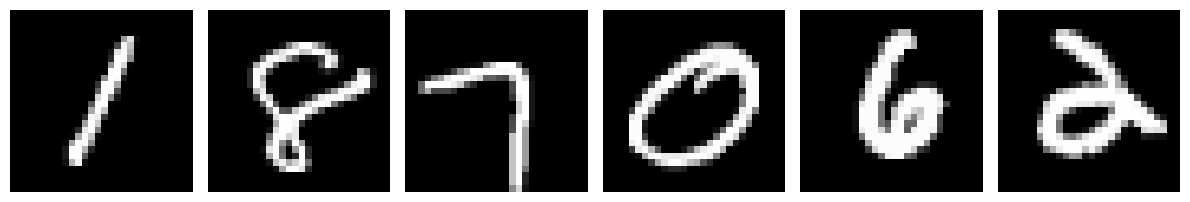

In [23]:
indices = np.random.choice(len(X_train), 6, replace= False)
selected_images = [X_train[i] for i in indices]

fig, axes = plt.subplots(1, 6, figsize=(12, 4))

for ax, img, in zip(axes, selected_images):
    ax.imshow(img, cmap="gray")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:
# Data Preprocessing

X_train = X_train.reshape(*X_train.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

# min-max scaling
X_train = X_train / 255
X_test = X_test / 255

In [25]:
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train = one_hot_encoder.fit_transform(y_train.reshape(-1, 1))
y_test = one_hot_encoder.transform(y_test.reshape(-1, 1))

## Model Defination

| Layer | Type | Configuration | Output |
|---|---|---|---|
| Input | Image/Input | 28 × 28 grayscale image | 28 × 28 = 784 pixels |
| Conv 1 | Convolution | 6 filters, 5 × 5, stride 1 | Feature maps |
| Pool 1 | Max Pooling | 2 × 2, stride 2 | Downsampled feature maps |
| Conv 2 | Convolution | 16 filters, 5 × 5, stride 1 | Feature maps |
| Pool 2 | Max Pooling | 2 × 2, stride 2 | Downsampled feature maps |
| FC 1 | Fully Connected | 120 perceptron | 120 |
| FC 2 | Fully Connected | 100 perceptron | 100 |
| Output | Fully Connected | 10 perceptron | 10 digit classes |

In [26]:
input_shape = X_train.shape[1:]
input_shape

(28, 28, 1)

In [27]:
input_layer = Input(shape=input_shape)

model = Sequential([
    input_layer,

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8949 - loss: 0.3419 - val_accuracy: 0.9743 - val_loss: 0.0848
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9674 - loss: 0.1081 - val_accuracy: 0.9824 - val_loss: 0.0600
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9758 - loss: 0.0823 - val_accuracy: 0.9866 - val_loss: 0.0497
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9808 - loss: 0.0653 - val_accuracy: 0.9882 - val_loss: 0.0451
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9834 - loss: 0.0551 - val_accuracy: 0.9881 - val_loss: 0.0466
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9858 - loss: 0.0463 - val_accuracy: 0.9887 - val_loss: 0.0405
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9877 - loss: 0.0407 - val_accuracy: 0.9899 - val_loss: 0.0368
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9889 - loss: 0.0356 - val_accu